In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
df = pd.read_csv('C:\\Users\\DELL\\Desktop\\DATA\\Python\\Revision Week days\\ML\\Decision tree\\Classification\\Placement_Data_Full_Class.csv')

In [3]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [4]:
df.drop(['salary'], axis = 1, inplace = True)

In [5]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [6]:
col = df.columns
col

Index(['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s',
       'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p',
       'status'],
      dtype='object')

In [7]:
for i in col:
    if df[i].dtype=='object':
        df[i] = le.fit_transform(df[i])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    int32  
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    int32  
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    int32  
 6   hsc_s           215 non-null    int32  
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    int32  
 9   workex          215 non-null    int32  
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    int32  
 12  mba_p           215 non-null    float64
 13  status          215 non-null    int32  
dtypes: float64(5), int32(8), int64(1)
memory usage: 16.9 KB


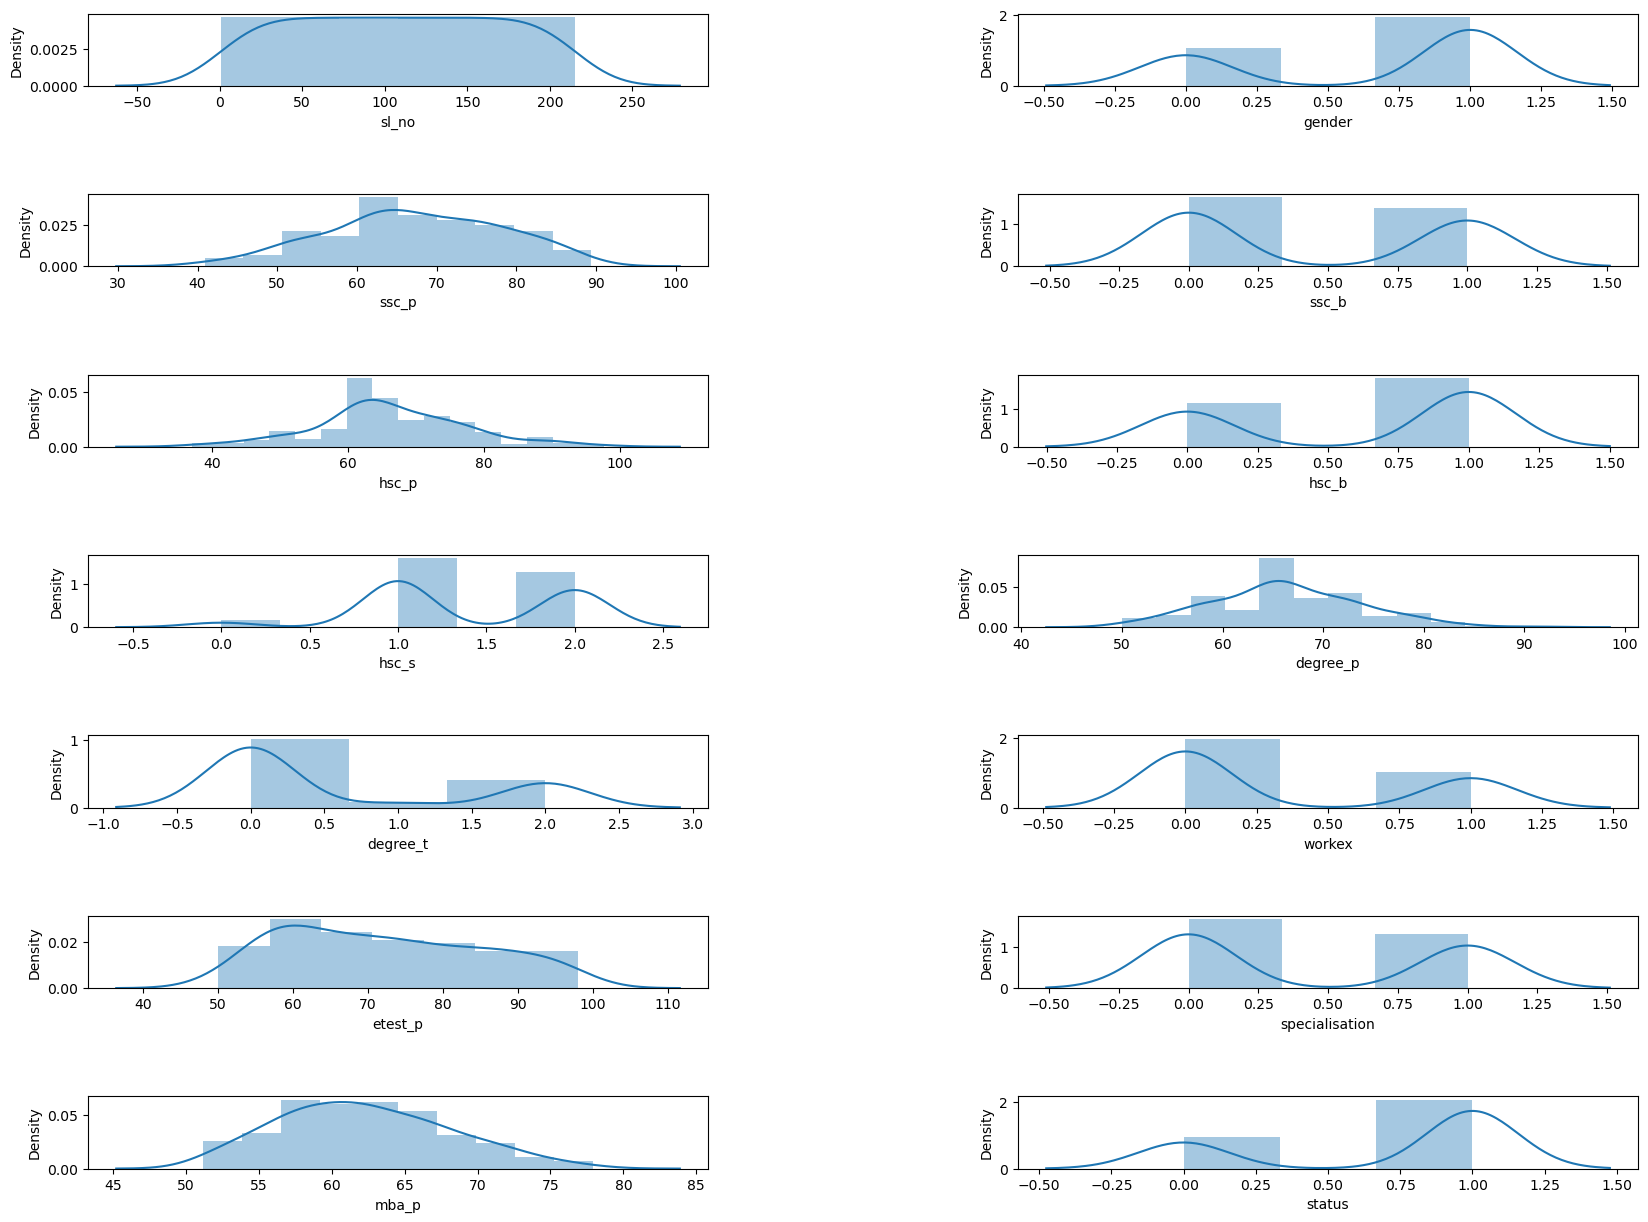

In [9]:
fig, axes = plt.subplots(7,2, figsize=(20,15)) 

for i in range(len(col)):
    
    plt.subplot(7,2,i+1)
    sns.distplot(df[df.columns[i]])
    
plt.subplots_adjust(hspace=1.5, wspace=0.5)

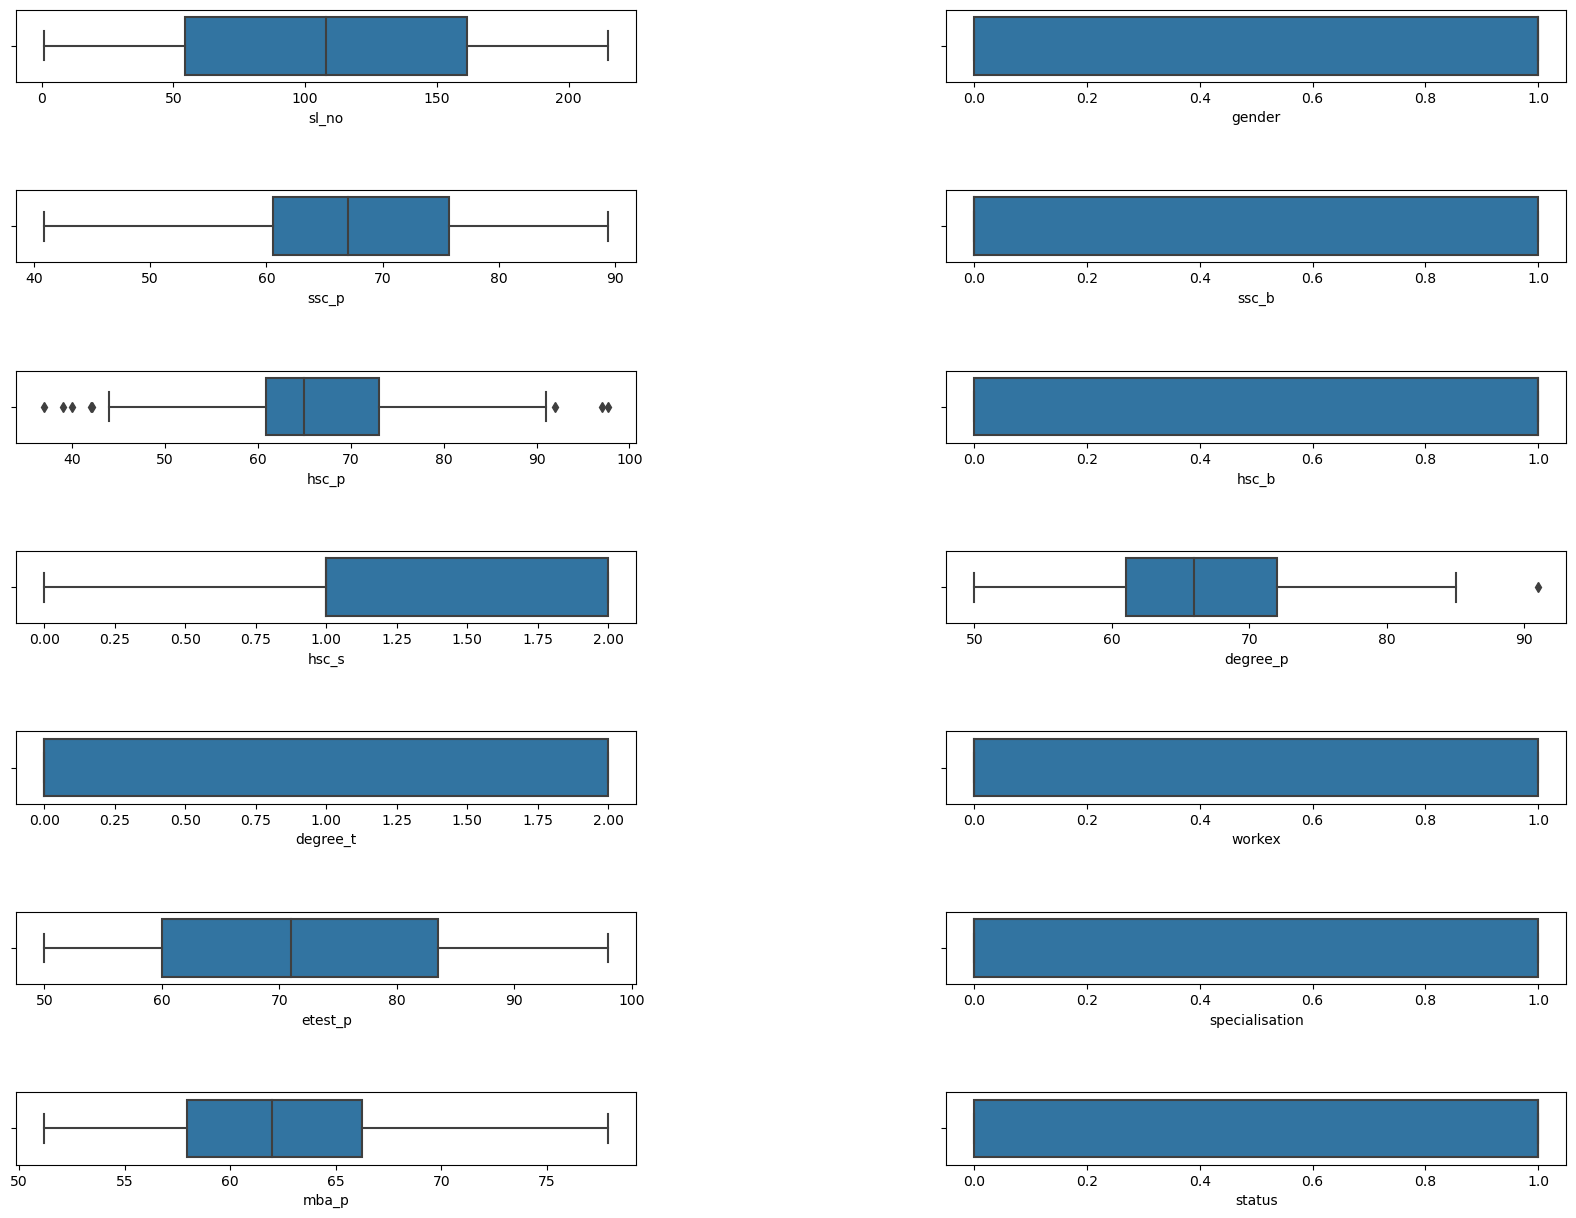

In [10]:
fig, axes = plt.subplots(7,2, figsize=(20,15)) 

for i in range(len(col)):
    
    plt.subplot(7,2,i+1)
    sns.boxplot(df[df.columns[i]])
    
plt.subplots_adjust(hspace=1.5, wspace=0.5)

In [11]:
x = df.drop(['status'], axis=1)
y = df['status']

In [12]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.feature_selection import RFECV 

from sklearn.model_selection import StratifiedKFold

In [13]:
rfe = RFECV(DecisionTreeClassifier(), cv=StratifiedKFold(3))

In [14]:
rfe.fit(x,y)

RFECV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=False),
      estimator=DecisionTreeClassifier())

In [15]:
rfe.ranking_

array([8, 7, 1, 5, 1, 6, 2, 1, 4, 1, 3, 1, 1])

In [16]:
rfe.n_features_

6

In [17]:
rfe.get_support()

array([False, False,  True, False,  True, False, False,  True, False,
        True, False,  True,  True])

In [18]:
feature_selected = x.columns[rfe.get_support()]
feature_selected

Index(['ssc_p', 'hsc_p', 'degree_p', 'workex', 'specialisation', 'mba_p'], dtype='object')

In [19]:
x = rfe.transform(x)

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [22]:
dtc = DecisionTreeClassifier()

In [23]:
dtc.fit(x_train,y_train)

DecisionTreeClassifier()

In [24]:
y_pred = dtc.predict(x_test)

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [30]:
cf = classification_report(y_test, y_pred)
print(cf)

              precision    recall  f1-score   support

           0       0.82      0.60      0.69        15
           1       0.81      0.93      0.87        28

    accuracy                           0.81        43
   macro avg       0.82      0.76      0.78        43
weighted avg       0.81      0.81      0.81        43



In [27]:
confusion_matrix(y_test, y_pred)

array([[ 9,  6],
       [ 2, 26]], dtype=int64)

In [28]:
accuracy_score(y_test, y_pred)

0.813953488372093

In [32]:
from sklearn import tree

In [39]:
plt.figure(figsize = (10,10)

tree.plot_tree(dtc)
plt.show()

SyntaxError: invalid syntax (2166814780.py, line 2)

In [ ]:
rfe.transform